<a href="https://colab.research.google.com/github/josethomas568/Vehicle-Auction-Price-Prediction-Engine/blob/main/Vehicle_Auction_Price_Prediction_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vehicle Auction Price Prediction Engine
~ Jose Thomas

In [55]:
import kagglehub
import os
import pandas as pd

# Download the dataset
path = kagglehub.dataset_download("tunguz/used-car-auction-prices")

# Find and load the CSV
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break

print(f"Loading data from: {os.path.basename(csv_file)}")
df = pd.read_csv(csv_file, on_bad_lines='skip')

print(f"Successfully loaded {len(df):,} rows.")
print("\nColumns available : ")
for col in df.columns:
    print(f"- {col}")

Using Colab cache for faster access to the 'used-car-auction-prices' dataset.
Loading data from: car_prices.csv
Successfully loaded 558,811 rows.

Columns available : 
- year
- make
- model
- trim
- body
- transmission
- vin
- state
- condition
- odometer
- color
- interior
- seller
- mmr
- sellingprice
- saledate


# 1. DATA INGESTION & CLEANING


In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb


print("Preparing dataset...")
df_clean = df.dropna(subset=['sellingprice', 'mmr']).copy()
df_clean['sellingprice'] = pd.to_numeric(df_clean['sellingprice'], errors='coerce')
df_clean['mmr'] = pd.to_numeric(df_clean['mmr'], errors='coerce')
df_clean = df_clean[(df_clean['sellingprice'] > 0) & (df_clean['mmr'] > 0)]
print(f"Dataset cleaned. {len(df_clean):,} rows remaining.")




Preparing dataset...
Dataset cleaned. 558,811 rows remaining.


# 2. EXPLORATORY DATA ANALYSIS (EDA)


## Target Variable Distribution

Generating Exploratory Data Analysis (EDA) visualizations...


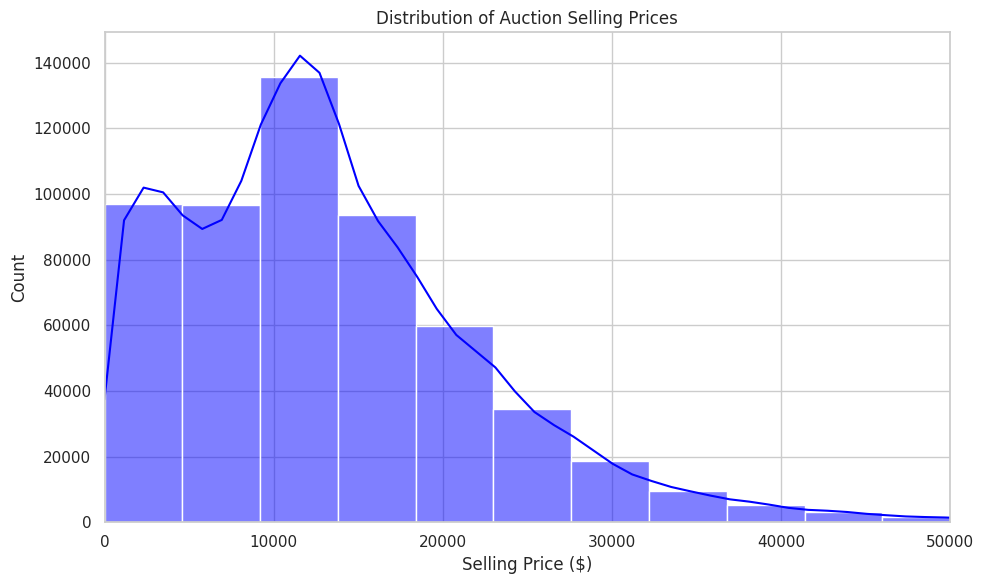

In [67]:
print("Generating Exploratory Data Analysis (EDA) visualizations...")
sns.set_theme(style="whitegrid")
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))

sns.histplot(df_clean['sellingprice'], bins=50, kde=True, ax=ax1, color='blue')
ax1.set_title('Distribution of Auction Selling Prices')
ax1.set_xlabel('Selling Price ($)')
ax1.set_xlim(0, 50000)
plt.tight_layout()
plt.show()

## The MMR Correlation

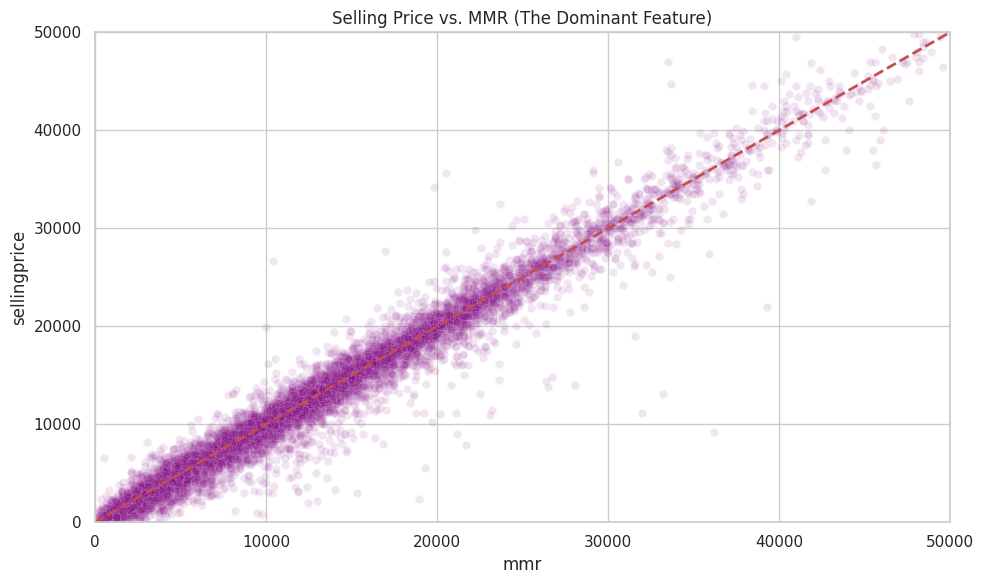

In [68]:
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))

sns.scatterplot(x='mmr', y='sellingprice', data=df_clean.sample(10000), alpha=0.1, ax=ax2, color='purple')
ax2.plot([0, 50000], [0, 50000], 'r--', lw=2)
ax2.set_title('Selling Price vs. MMR (The Dominant Feature)')
ax2.set_xlim(0, 50000)
ax2.set_ylim(0, 50000)
plt.tight_layout()
plt.show()

## Correlation Heatmap of Numeric Features

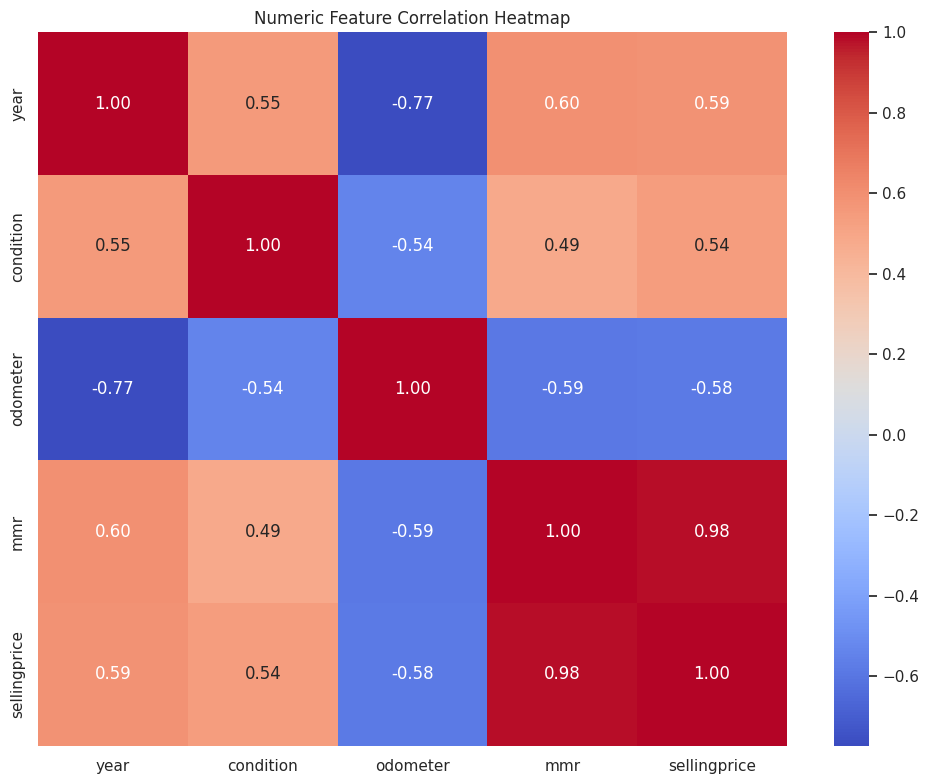

In [69]:
fig3, ax3 = plt.subplots(1, 1, figsize=(10, 8))

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax3)
ax3.set_title('Numeric Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Impact of Condition on Price

/tmp/ipykernel_2662/3953189092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=pd.qcut(df_clean['condition'], q=4, duplicates='drop'), y='sellingprice', data=df_clean, ax=ax4, palette='Set2')


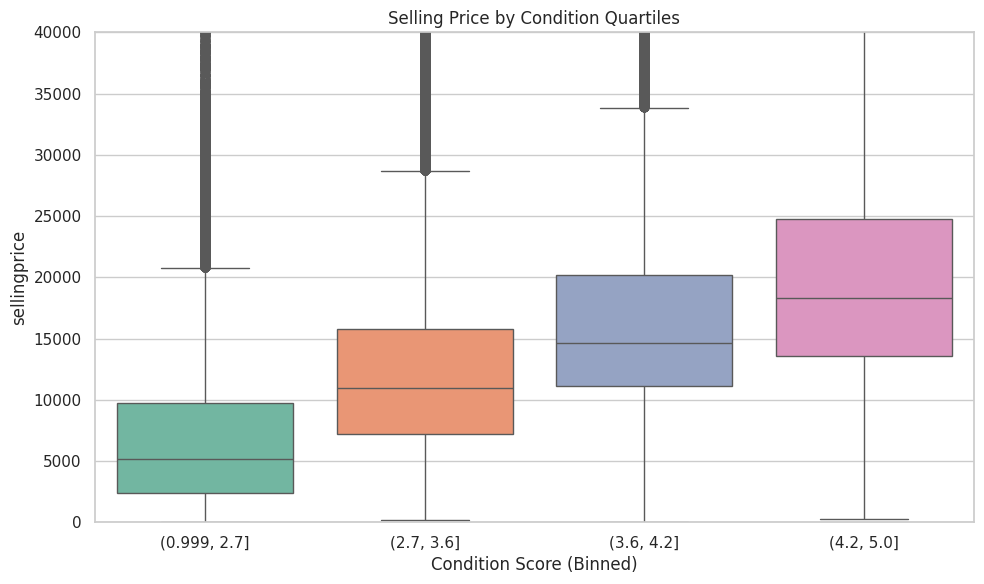

In [70]:
fig4, ax4 = plt.subplots(1, 1, figsize=(10, 6))

df_clean['condition'] = pd.to_numeric(df_clean['condition'], errors='coerce')
sns.boxplot(x=pd.qcut(df_clean['condition'], q=4, duplicates='drop'), y='sellingprice', data=df_clean, ax=ax4, palette='Set2')
ax4.set_title('Selling Price by Condition Quartiles')
ax4.set_xlabel('Condition Score (Binned)')
ax4.set_ylim(0, 40000)
plt.tight_layout()
plt.show()

# 3. FEATURE ENGINEERING PIPELINE


In [71]:

def engineer_car_features(input_df, top_n_categories=15):
    print("Executing feature engineering pipeline...")
    df_eng = input_df.copy()

    df_eng['odometer'] = pd.to_numeric(df_eng['odometer'], errors='coerce')
    df_eng['Odometer_Missing'] = np.where((df_eng['odometer'].isna()) | (df_eng['odometer'] == 0), 1, 0)
    df_eng['odometer'] = df_eng['odometer'].fillna(df_eng['odometer'].median())

    df_eng['year'] = pd.to_numeric(df_eng['year'], errors='coerce')
    df_eng['Vehicle_Age'] = 2026 - df_eng['year']

    df_eng['Condition_Missing'] = np.where(df_eng['condition'].isna(), 1, 0)
    df_eng['condition'] = df_eng['condition'].fillna(df_eng['condition'].median())

    categorical_cols = ['make', 'model', 'body', 'state', 'color', 'transmission']
    for col in categorical_cols:
        if col in df_eng.columns:
            df_eng[col] = df_eng[col].astype(str).str.upper().str.strip()
            top_vals = df_eng[col].value_counts().nlargest(top_n_categories).index.tolist()
            df_eng[col] = df_eng[col].apply(lambda x: x if x in top_vals else 'OTHER_VAL')

    # Force integers for one-hot encoding
    df_eng = pd.get_dummies(df_eng, columns=categorical_cols, prefix=[c.title() for c in categorical_cols], drop_first=False, dtype=int)

    return df_eng

processed_df = engineer_car_features(df_clean)



Executing feature engineering pipeline...


# 4. DATA SPLITTING (DELTA ARCHITECTURE)


In [ ]:

X = processed_df.select_dtypes(include=[np.number]).drop(columns=['sellingprice', 'year', 'mmr'], errors='ignore')

y_absolute = processed_df['sellingprice']
y_delta = processed_df['sellingprice'] - processed_df['mmr']

print(f"Final matrices configured: {X.shape[0]:,} samples with {X.shape[1]} engineered features.")

imputer = SimpleImputer(strategy='median')
X_imputed_array = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns, index=X.index)

X_train, X_test, y_train_abs, y_test_abs = train_test_split(X_imputed, y_absolute, test_size=0.2, random_state=42)
_, _, y_train_delta, y_test_delta = train_test_split(X_imputed, y_delta, test_size=0.2, random_state=42)



Final matrices configured: 558,811 samples with 88 engineered features.


# 5. MODELING (BASELINE VS DELTA BOOSTING)


## Baseline Linear Regression (predicts absolute price)

In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train_abs)
baseline_preds = baseline_model.predict(X_test)
baseline_rmse = root_mean_squared_error(y_test_abs, baseline_preds)
print(f"\n[1/3] Baseline Linear Regression RMSE: ${baseline_rmse:,.2f}")

## XGBoost (predicts delta without mmr in the features)

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train_delta)
xgb_delta_preds = xgb_model.predict(X_test)
xgb_final_preds = xgb_delta_preds + processed_df.loc[X_test.index, 'mmr'].values
xgb_rmse = root_mean_squared_error(y_test_abs, xgb_final_preds)
print(f"[2/3] XGBoost Regressor RMSE: ${xgb_rmse:,.2f}")


[1/3] Baseline Linear Regression RMSE: $5,778.36
[2/3] XGBoost Regressor RMSE: $1,474.82
[3/3] LightGBM Regressor RMSE: $1,478.63

Gradient Boosting achieved a 74.48% improvement in RMSE over baseline.


## LightGBM (predicts delta without mmr in the features)

In [ ]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, random_state=42, n_jobs=-1, verbosity=-1
)
lgb_model.fit(X_train, y_train_delta)
lgb_delta_preds = lgb_model.predict(X_test)
lgb_final_preds = lgb_delta_preds + processed_df.loc[X_test.index, 'mmr'].values
lgb_rmse = root_mean_squared_error(y_test_abs, lgb_final_preds)
print(f"[3/3] LightGBM Regressor RMSE: ${lgb_rmse:,.2f}")

best_rmse = min(xgb_rmse, lgb_rmse)
pct_improvement = ((baseline_rmse - best_rmse) / baseline_rmse) * 100
print(f"\nGradient Boosting achieved a {pct_improvement:.2f}% improvement in RMSE over baseline.")

# 6. EXPORTING MODEL

In [31]:
import joblib

print("Exporting model artifacts for deployment...")

# Save the winning XGBoost model
xgb_model.save_model("xgb_auction_model.json")

# Save the imputer and the exact feature columns expected by the model
artifacts = {
    'imputer': imputer,
    'columns': list(X.columns)
}
joblib.dump(artifacts, "model_artifacts.pkl")

print("Export complete! Files saved: xgb_auction_model.json, model_artifacts.pkl")

Exporting model artifacts for deployment...
Export complete! Files saved: xgb_auction_model.json, model_artifacts.pkl


In [30]:
from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib

app = Flask(__name__)

# Load Model and Artifacts on startup
print("Loading model and artifacts...")
model = xgb.XGBRegressor()
model.load_model("xgb_auction_model.json")

artifacts = joblib.load("model_artifacts.pkl")
imputer = artifacts['imputer']
expected_columns = artifacts['columns']

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Get JSON data from the incoming request
        data = request.get_json()

        # 2. Convert to DataFrame
        input_df = pd.DataFrame([data])

        # Ensure the baseline mmr is provided
        if 'mmr' not in input_df.columns:
            return jsonify({'error': 'Missing required baseline value: mmr'}), 400

        base_mmr = float(input_df['mmr'].iloc[0])

        # 3. Quick Feature Alignment
        input_df = pd.get_dummies(input_df)

        # Reindex to match the training columns perfectly, filling missing dummies with 0
        X_api = input_df.reindex(columns=expected_columns, fill_value=0)

        # 4. Impute missing numeric values
        X_imputed = imputer.transform(X_api)

        # 5. Predict the Delta and calculate Final Price
        predicted_delta = model.predict(X_imputed)[0]
        final_price = base_mmr + predicted_delta

        # 6. Return the JSON response
        return jsonify({
            'status': 'success',
            'baseline_mmr': round(base_mmr, 2),
            'predicted_markup_discount': round(float(predicted_delta), 2),
            'final_predicted_price': round(float(final_price), 2)
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 500

import threading

def run_api():
    # use_reloader=False is mandatory when running inside a background thread
    app.run(host='127.0.0.1', port=5000, debug=False, use_reloader=False)

# Spin up the Flask server in a background thread
api_thread = threading.Thread(target=run_api)
# Setting daemon=True ensures the server dies when you close the notebook
api_thread.daemon = True
api_thread.start()

print("Flask API is now running in the background! ")

Loading model and artifacts...
 * Serving Flask app '__main__'
✅ Flask API is now running in the background! You can run the next cell.
 * Debug mode: off


In [32]:
import requests
import json

# 1. Define the API endpoint (pointing to your localhost)
url = 'http://127.0.0.1:5000/predict'

# 2. Create a mock JSON payload (An order for the model)
# We are asking it to price a 2020 Ford F-150 in great condition with 35k miles.
mock_vehicle_data = {
    "year": 2020,
    "condition": 4.5,
    "odometer": 35000,
    "mmr": 18500,
    "Make_FORD": 1,
    "Model_F-150": 1
}

# 3. Send the POST request to the Flask server
try:
    print("Sending vehicle data to the API...")
    response = requests.post(url, json=mock_vehicle_data)

    # 4. Print the server's response
    print("\n--- SERVER RESPONSE ---")
    print(json.dumps(response.json(), indent=4))

except Exception as e:
    print(f"Error connecting to the API: {e}")

INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 19:11:27] "POST /predict HTTP/1.1" 200 -


Sending vehicle data to the API...

--- SERVER RESPONSE ---
{
    "baseline_mmr": 18500.0,
    "final_predicted_price": 18591.03,
    "predicted_markup_discount": 91.03,
    "status": "success"
}


In [77]:
# Use an official Python runtime as a parent image
FROM python:3.9-slim

# Set the working directory in the container
WORKDIR /app

# Leverage Docker cache by copying and installing requirements first
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the application code into the container
COPY . .

# Expose port 5000
EXPOSE 5000

# Define environment variable for Flask
ENV FLASK_APP=flask_api.py

# Run the Flask app using Gunicorn WSGI server
CMD exec gunicorn --bind :$PORT --workers 1 --threads 8 --timeout 0 flask_api:app

Writing Dockerfile


In [78]:
%%writefile requirements.txt
flask
requests
pandas
numpy
xgboost
scikit-learn
joblib
gunicorn # for production server

Writing requirements.txt


In [79]:
%%writefile flask_api.py
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load Model and Artifacts on startup
print("Loading model and artifacts...")
model = xgb.XGBRegressor()
model.load_model("xgb_auction_model.json")

artifacts = joblib.load("model_artifacts.pkl")
imputer = artifacts['imputer']
expected_columns = artifacts['columns']

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Get JSON data from the incoming request
        data = request.get_json()

        # 2. Convert to DataFrame
        input_df = pd.DataFrame([data])

        # Ensure the baseline mmr is provided
        if 'mmr' not in input_df.columns:
            return jsonify({'error': 'Missing required baseline value: mmr'}), 400

        base_mmr = float(input_df['mmr'].iloc[0])

        # 3. Quick Feature Alignment
        input_df = pd.get_dummies(input_df)

        # Reindex to match the training columns perfectly, filling missing dummies with 0
        X_api = input_df.reindex(columns=expected_columns, fill_value=0)

        # 4. Impute missing numeric values
        X_imputed = imputer.transform(X_api)

        # 5. Predict the Delta and calculate Final Price
        predicted_delta = model.predict(X_imputed)[0]
        final_price = base_mmr + predicted_delta

        # 6. Return the JSON response
        return jsonify({
            'status': 'success',
            'baseline_mmr': round(base_mmr, 2),
            'predicted_markup_discount': round(float(predicted_delta), 2),
            'final_predicted_price': round(float(final_price), 2)
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 500


Writing flask_api.py


#

# 7. TEST

In [ ]:
import requests
import json

url = 'https://<YOUR_CLOUD_RUN_URL>/predict'

# The test payload
mock_vehicle_data = {
    "year": 2020,
    "condition": 4.5,
    "odometer": 35000,
    "mmr": 18500,
    "Make_FORD": 1,
    "Model_F-150": 1
}

print(f"Sending payload to Google Cloud Platform...")
print(f"URL: {url}")

try:
    response = requests.post(url, json=mock_vehicle_data)

    print("\n--- GCP SERVER RESPONSE ---")
    print(json.dumps(response.json(), indent=4))

except Exception as e:
    print(f"Error connecting to GCP: {e}")